#3. Visualizar el eventing data 
Una vez entendida la estructura de las carpetas del eventing data, vamos a proceder a la visualización de los diferentes eventos dentro de un campo de fútbol. Vamos antes a ver de qué manera podemos graficar un campo de fútbol 


In [2]:
import matplotlib.pyplot as plt

#3.1. Graficar un campo de fútbol
Tenemos muchas maneras de graficar un campo de fútbol, para esta parte utilizaremos el enfoque más inteligente y directo, ya que a nosotros nos preocupa el análisis del evento en sí y no la graficación del campo. Por ello vamos a utilizar una nueva librería de python sobre fútbol que tiene una función que nos permitirá graficar de una manera muy sencilla un campo de fútbol, esta librería es mplsoccer. 

Primero necesitamos instalar la nueva librería que no se encuentra en google colab, pero ya sabemos los comandos para instalar una nueva librería en nuestro notebook. 


In [3]:
!pip install mplsoccer

     |████████████████████████████████| 61kB 5.1MB/s 
  Created wheel for mplsoccer: filename=mplsoccer-1.0.5-cp37-none-any.whl size=62948 sha256=09446ae91dd841917a4bd8b0893ef4ddb8391380b94c9be6c0efb44c5af8111b
  Stored in directory: /root/.cache/pip/wheels/1e/89/34/a6679a2c0b05f035f97ccc671f73139d2859b7612995416d2a
Successfully built mplsoccer


Una vez instalada importamos el método Pitch y VerticalPitch

In [4]:
from mplsoccer.pitch import Pitch, VerticalPitch

Gracias al método Pitch, con la siguiente línea de código obtendremos un campo de fútbol bien bonito y de manera sencilla. 

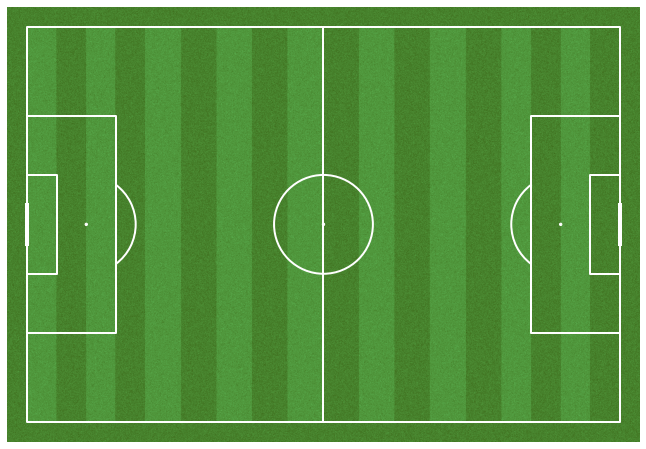

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color ='grass', line_color='white', stripe=True)
pitch.draw(ax=ax)

Como veis en unas simples líneas de código, gracias a la librería mplsoccer hemos podido graficar un campo de fútbol. Si quitamos el parámetro stripe tendremos un campo de fútbol verde sin las sombras. 

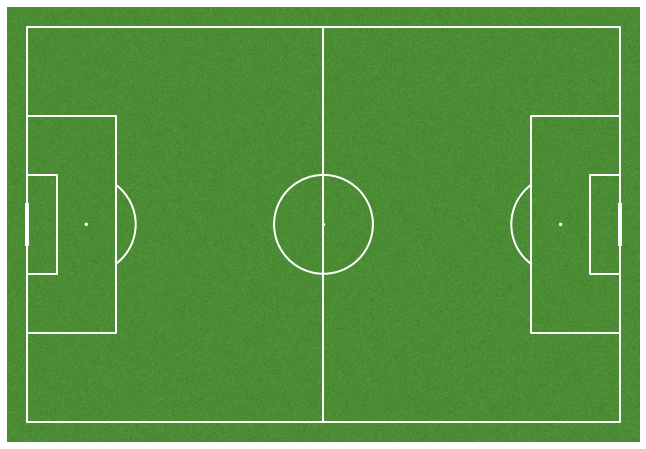

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color ='grass', line_color='white')
pitch.draw(ax=ax)

## 3.1.1. Cambiar el color al campo
También podemos cambiar el color del campo, a un campo blanco con las líneas negras, gracias al parámetro pitch_color y line_color


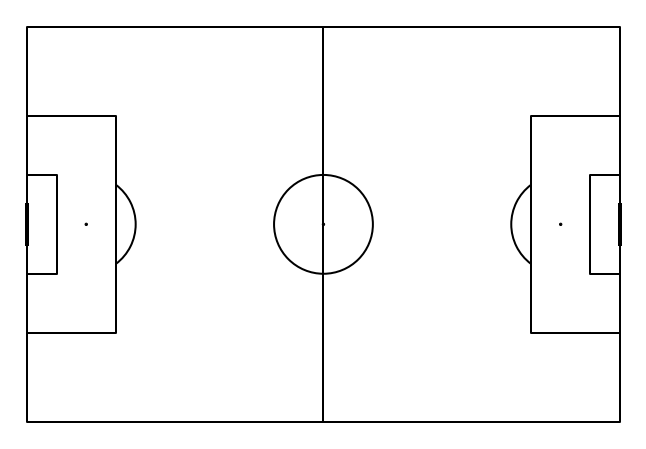

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color ='white', line_color='black')
pitch.draw(ax=ax)

De la misma manera podemos obtener un campo de futbol de color negro con lineas blancas. 

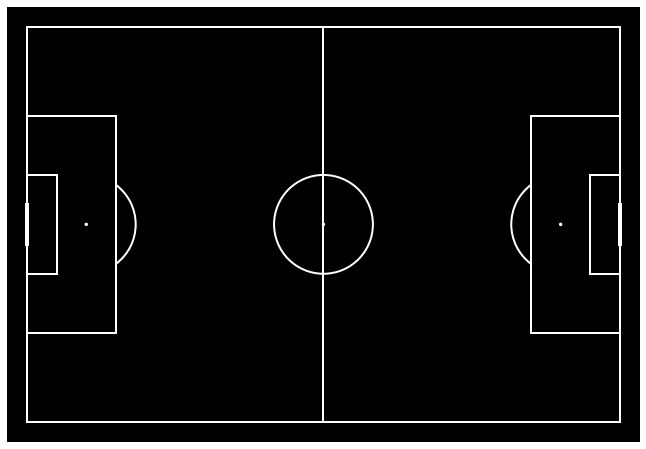

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color ='black', line_color='white')
pitch.draw(ax=ax)

Como veis tenemos maneras muy sencillas de graficar diferentes tipos de campos de fútbol, dependiendo de qué estilo nos guste más.

## 3.1.2. Añadir el tamaño del campo 
Con los parámetros axis, label y tick podremos ver el tamaño del campo de fútbol, para ver sus coordenadas. 

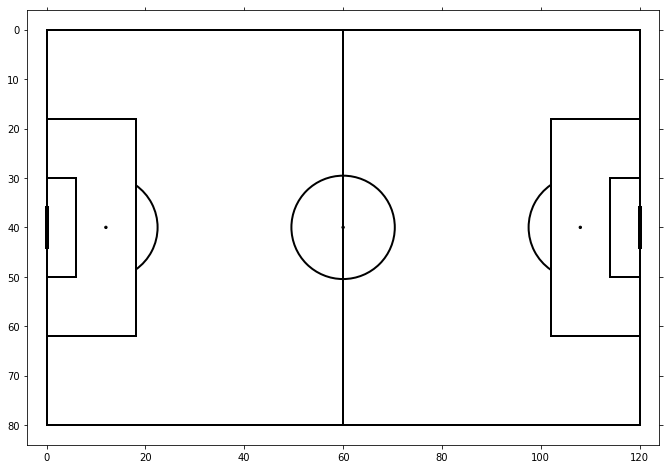

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color ='white', line_color='black',axis=True, label=True, tick=True)
pitch.draw(ax=ax)

## 3.1.3. Cambiar el tamaño del campo en función del proveedor
Como ya sabemos, existen diferentes tipos de proveedores de datos y cada uno tiene su propia manera de recoger las coordenadas de los eventos. Por tanto, los diferentes proveedores tienen diferentes tamaños de campos. De manera predeterminada el método Pitch nos grafica un campo con el tamaño del proveedor Statsbomb. Pero si especificamos otro proveedor al parámetro pitch_type, veremos como cambia el tamaño del campo.


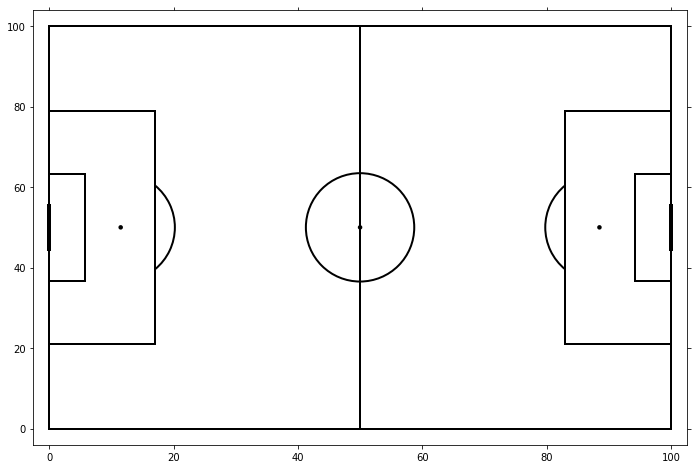

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_type='opta',pitch_color ='white', line_color='black',axis=True, label=True, tick=True)
pitch.draw(ax=ax)

Como veis, el tamaño del campo para Opta es de 100 x 100, mientras que para Statsbomb es de 120 x 80. Estos conceptos son importantes a la hora de graficar los eventos, ya que vienen con unas coordenadas diferentes, dependiendo del proveedor de datos. Pero con Pitch y el parámetro picth_type no necesitamos hacer transformaciones a las coordenadas para poder graficarlas. 

## 3.1.4. Graficar la mitad de un campo 
Con el parámetro half podremos graficar la mitad del campo. 

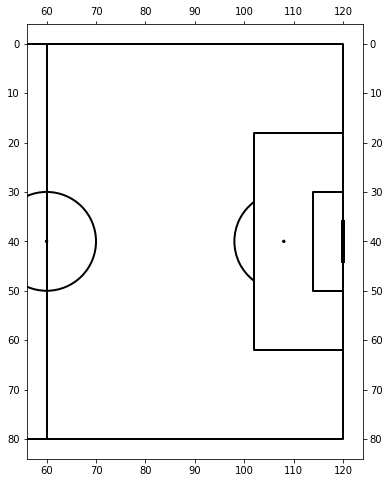

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color ='white',  half=True, line_color='black',axis=True, label=True, tick=True,)
pitch.draw(ax=ax)

## 3.1.5. Graficar un campo de manera vertical 
Con VerticalPitch podremos graficar un campo de fútbol de manera vertical y más el parámetro half nos mostrará solo una parte del campo.

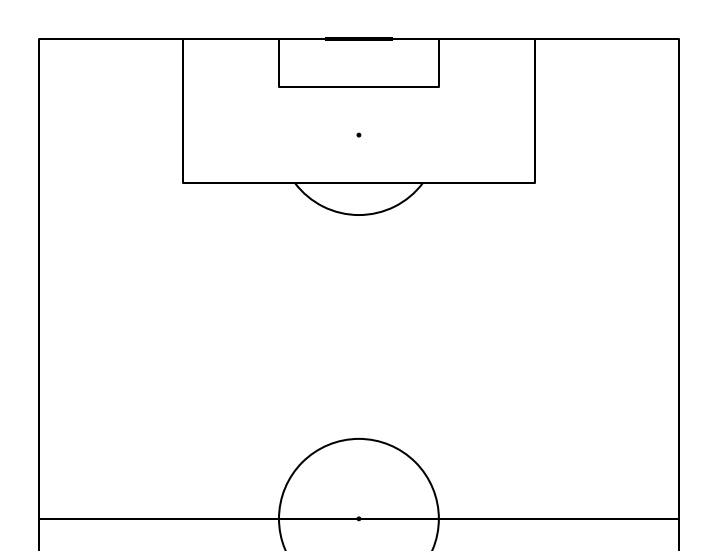

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
pitch = VerticalPitch(pitch_color ='white',  half=True,line_color='black')
pitch.draw(ax=ax)

Si quitamos el parámetro half, obtendremos el campo de manera vertical. 

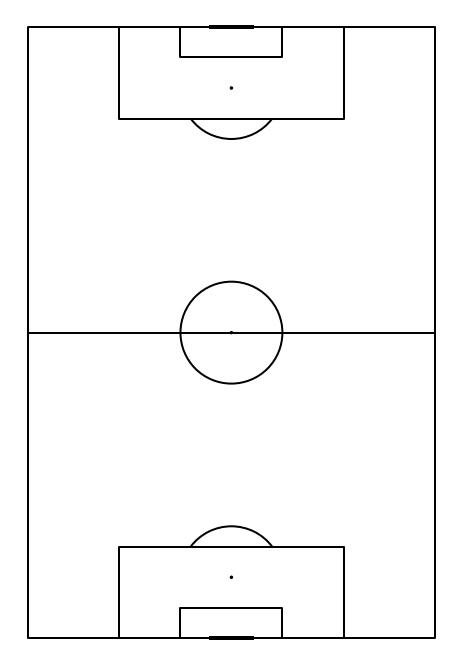

In [ ]:
fig, ax = plt.subplots(figsize=(16,12))
pitch = VerticalPitch(pitch_color ='white',line_color='black')
pitch.draw(ax=ax)

##3.1.6. Añadir las diferentes posiciones del campo 
Gracias al parámetro positional, podremos ver en el campo de fútbol las diferentes posiciones dentro del campo.


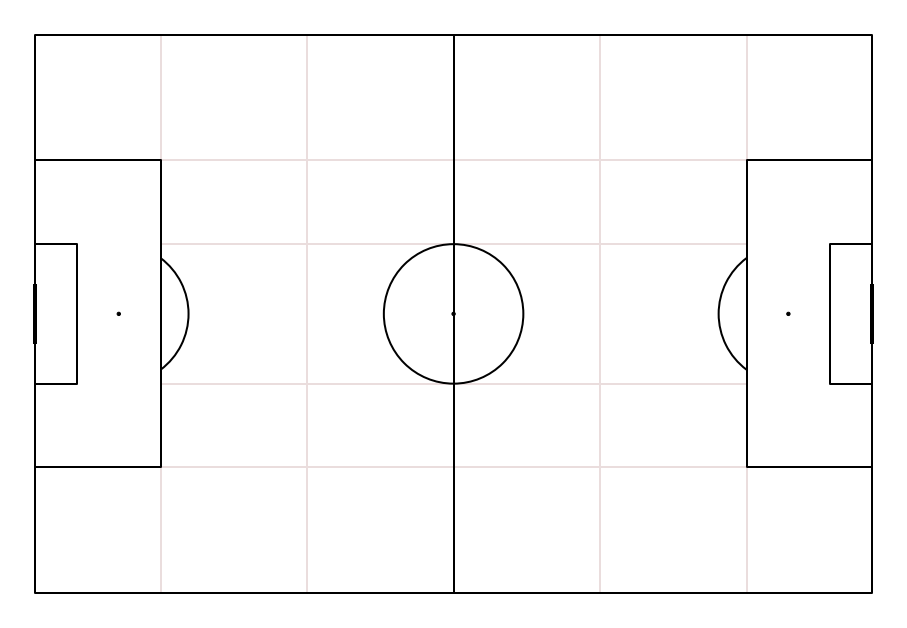

In [ ]:
fig, ax = plt.subplots(figsize=(16,12))
pitch = Pitch(pitch_color ='white',line_color='black', positional=True)
pitch.draw(ax=ax)

Ahora que ya conocemos las diferentes maneras de graficar un campo de fútbol, podemos empezar a graficar los diferentes eventos. Para graficar los eventos vamos a importar las funciones que creamos en la parte de automatización para la obtención del eventing data. 

In [5]:
import pandas as pd
import json
import sys

Como siempre utilizaremos la librería sys para añadir nuestras funciones en forma de librería.

In [6]:
sys.path.append('/content/drive/MyDrive/Mi curso/Functions')

Una vez añadido el path donde se encuentran nuestra funciones, podemos importar las funciones que automatizan la obtención del eventing data, como si fuera una librería.

In [7]:
import functions as f

# 3.2. Visualizar el eventing tiros 
Ahora solo necesitamos acceder al partido que queramos, gracias a las funciones que ya creamos. Volvemos a  utilizar la función info_json() para seleccionar la competición y la temporada.

In [ ]:
matches = f.info_json('/content/drive/MyDrive/Mi curso/Data/event_data/Statsbomb/data')
matches

**************************************
                Competition
id                         
16         Champions League
37  FA Women's Super League
43           FIFA World Cup
11                  La Liga
49                     NWSL
2            Premier League
72        Women's World Cup 

Que competición quieres analizar: 16
**************************************
       Season
id           
4   2018/2019
1   2017/2018
2   2016/2017
27  2015/2016
26  2014/2015
25  2013/2014
24  2012/2013
23  2011/2012
22  2010/2011
21  2009/2010
41  2008/2009
39  2006/2007
37  2004/2005
44  2003/2004
76  1999/2000 

Que temporada quieres analizar: 4


,home_team,away_team,home_score,away_score,match_date,competition,stage
match_id,,,,,,,
22912,Tottenham Hotspur,Liverpool,0,2,2019-06-01,Champions League,Final



Una vez seleccionado el partido obtenemos el evento tiro, con la función de event_data().

In [ ]:
shots = f.event_data('/content/drive/MyDrive/Mi curso/Data/event_data/Statsbomb/data/events', 22912)

['Starting XI' 'Half Start' 'Pass' 'Ball Receipt*' 'Carry' 'Duel'
 'Pressure' 'Foul Committed' 'Shot' 'Goal Keeper' 'Clearance'
 'Ball Recovery' 'Foul Won' 'Interception' 'Miscontrol' 'Dispossessed'
 'Dribbled Past' 'Dribble' '50/50' 'Block' 'Shield' 'Injury Stoppage'
 'Referee Ball-Drop' 'Half End' 'Substitution' 'Tactical Shift' 'Offside'] 

Que evento quieres analizar: Shot


Con el método .scatter() de Pitch(), podemos fácilmente graficar los tiros, pasándole por parámetro las columnas location_x y  location_y.

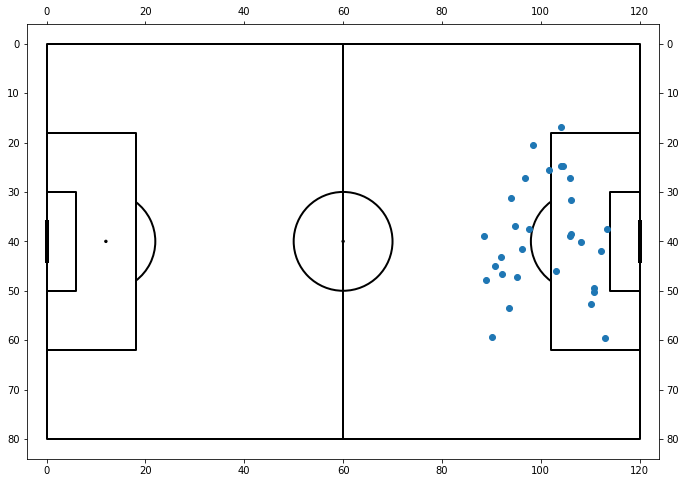

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color='white', line_color='black',tick=True, axis=True, label=True)
pitch.draw(ax=ax)
pitch.scatter(shots.location_x, shots.location_y, ax=ax)

Pero si nos fijamos nos grafica todos los tiros en un lado del campo, aunque los tiros fueron de equipos distintos.

In [ ]:
shots.team_name.values

array(['Liverpool', 'Tottenham Hotspur', 'Liverpool', 'Liverpool',
       'Liverpool', 'Liverpool', 'Liverpool', 'Liverpool', 'Liverpool',
       'Tottenham Hotspur', 'Liverpool', 'Liverpool', 'Tottenham Hotspur',
       'Tottenham Hotspur', 'Tottenham Hotspur', 'Tottenham Hotspur',
       'Liverpool', 'Tottenham Hotspur', 'Tottenham Hotspur',
       'Tottenham Hotspur', 'Tottenham Hotspur', 'Tottenham Hotspur',
       'Liverpool', 'Tottenham Hotspur', 'Tottenham Hotspur', 'Liverpool',
       'Liverpool', 'Tottenham Hotspur', 'Tottenham Hotspur',
       'Tottenham Hotspur'], dtype=object)

## 3.2.1. Visualizar los tiros de ambos equipos
Vamos a tener que crear un bucle for, para cada vez que el nombre del equipo coincida, graficar los tiros de dicho equipo y de un determinado color, para su diferenciación. También algo muy importante es que tenemos que graficar los goles de un equipo en un lado del campo y del otro equipo en el otro lado del campo. 

Por ejemplo el equipo visitante lo graficamos en el lado izquierdo, para hacerlo tendremos que restar a la coordenada de cada tiro el tamaño del campo tanto en la x como la y.

 

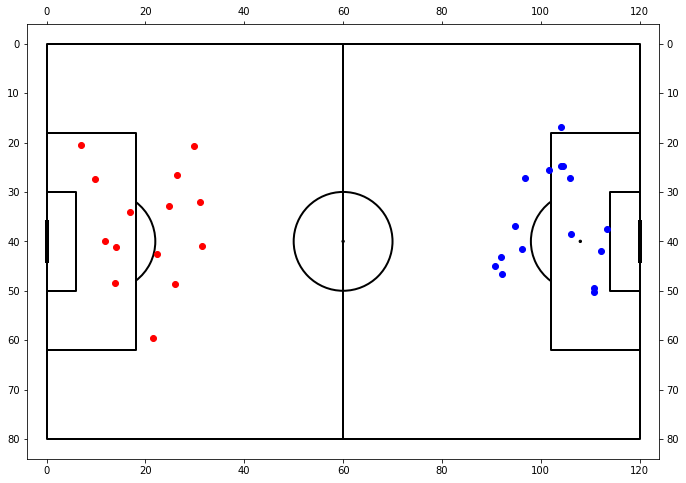

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color='white', line_color='black',tick=True, axis=True, label=True)
pitch.draw(ax=ax)

for i in range(len(shots)):

  if shots.team_name.values[i] == 'Liverpool':
    pitch.scatter(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], ax=ax, color='red')

  elif shots.team_name.values[i] == 'Tottenham Hotspur':
    pitch.scatter(shots.location_x.values[i], shots.location_y.values[i], ax=ax, color='blue')

## 3.2.2. Mostrar el tamaño del punto en función del xG
Ahora sí tenemos cada tiro de cada equipo. Lo que haremos ahora será añadir el tamaño del punto en función del xG, pero como es un valor muy pequeño lo multiplicaremos por 1000 para que sea proporcional al campo.  


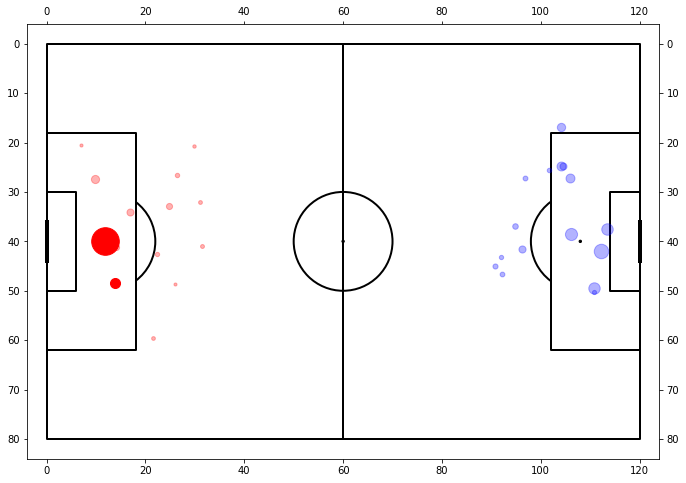

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color='white', line_color='black',tick=True, axis=True, label=True)
pitch.draw(ax=ax)

for i in range(len(shots)):

  if shots.team_name.values[i] == 'Liverpool':

    if shots.shot_outcome_name.values[i] == 'Goal':
      pitch.scatter(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], ax=ax, color='red', s=shots.shot_statsbomb_xg.values[i]*1000)
    else:
      pitch.scatter(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], ax=ax, color='red', s=shots.shot_statsbomb_xg.values[i]*1000, alpha=0.3)

  elif shots.team_name.values[i] == 'Tottenham Hotspur':

    if shots.shot_outcome_name.values[i] == 'Goal':
      pitch.scatter(shots.location_x.values[i], shots.location_y.values[i], ax=ax, color='blue', s=shots.shot_statsbomb_xg.values[i]*1000)
    else:
      pitch.scatter(shots.location_x.values[i], shots.location_y.values[i], ax=ax, color='blue', s=shots.shot_statsbomb_xg.values[i]*1000, alpha=0.3)

## 3.2.3. Añadir texto al campo de fútbol 
Vamos a seguir mejorando el gráfico, añadiendo texto con plt.text() y un título con plt.title() 

Con plt.text() añadiremos la zona del campo que corresponde a cada equipo y con plt.title() indicaremos la información del partido, tanto competición, fecha, y equipos. Utilizaremos el método .format() para pasar toda esa información.

Text(0.5, 1.0, 'Final de la Champions')

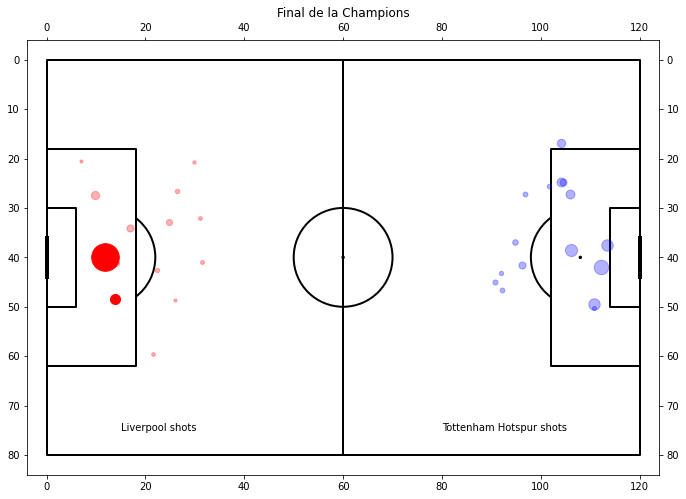

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color='white', line_color='black',tick=True, axis=True, label=True)
pitch.draw(ax=ax)

for i in range(len(shots)):

  if shots.team_name.values[i] == 'Liverpool':

    if shots.shot_outcome_name.values[i] == 'Goal':
      pitch.scatter(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], ax=ax, color='red', s=shots.shot_statsbomb_xg.values[i]*1000)
    else:
      pitch.scatter(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], ax=ax, color='red', s=shots.shot_statsbomb_xg.values[i]*1000, alpha=0.3)

  elif shots.team_name.values[i] == 'Tottenham Hotspur':

    if shots.shot_outcome_name.values[i] == 'Goal':
      pitch.scatter(shots.location_x.values[i], shots.location_y.values[i], ax=ax, color='blue', s=shots.shot_statsbomb_xg.values[i]*1000)
    else:
      pitch.scatter(shots.location_x.values[i], shots.location_y.values[i], ax=ax, color='blue', s=shots.shot_statsbomb_xg.values[i]*1000, alpha=0.3)

plt.text(15, 5, matches.away_team.values[0] + ' shots') 
plt.text(80, 5, matches.home_team.values[0] + ' shots')
plt.title('{} {} - {} Vs {}'.format(matches.competition.values[0], matches.match_date.values[0], matches.home_team.values[0], matches.away_team.values[0]), fontsize=16)
plt.show()

## 3.2.4. Añadir el nombre de los jugadores
Otra mejora para el gráfico, es añadir el nombre del jugadores una vez se marca gol. Podemos acceder al nombre de los jugadores que realizan los tiros con 'player_name'.

In [ ]:
shots.player_name

33                       Mohamed Salah
341                     Moussa Sissoko
586             Trent Alexander-Arnold
757                      Mohamed Salah
767                      Mohamed Salah
1346                  Andrew Robertson
1352                     Mohamed Salah
1401            Jordan Brian Henderson
1422                     Mohamed Salah
1560       Christian Dannemann Eriksen
1884            Fábio Henrique Tavares
1915                     Mohamed Salah
1959                     Bamidele Alli
2032                        Danny Rose
2038                    Jan Vertonghen
2177       Christian Dannemann Eriksen
2434               James Philip Milner
2581                     Bamidele Alli
2793                     Bamidele Alli
2843                     Heung-Min Son
2850    Lucas Rodrigues Moura da Silva
2886                     Heung-Min Son
2912            Jordan Brian Henderson
2942       Christian Dannemann Eriksen
2947    Lucas Rodrigues Moura da Silva
2970                   Vi


Para añadir el nombre de los jugadores que han marcado un gol, justo después de la parte del código que se encarga de graficar el gol, añadiremos con plt.text() las coordenadas de dicho gol y el nombre del jugadores. Gracias al bucle for podemos saber que jugador es. 

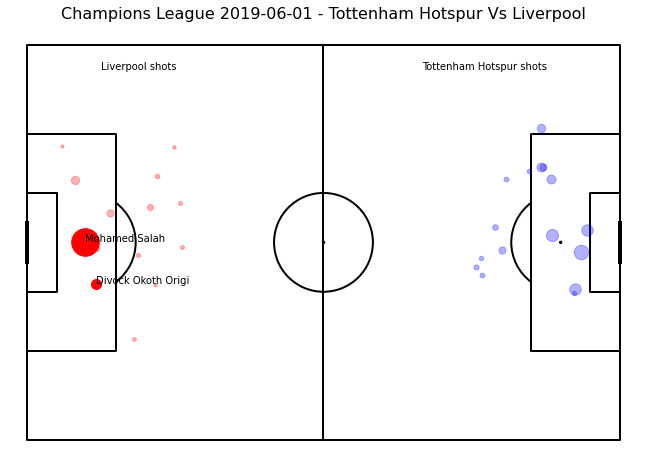

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
pitch = Pitch(pitch_color='white', line_color='black')
pitch.draw(ax=ax)

for i in range(len(shots)):

  if shots.team_name.values[i] == 'Liverpool':

    if shots.shot_outcome_name.values[i] == 'Goal':
      pitch.scatter(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], ax=ax, color='red', s=shots.shot_statsbomb_xg.values[i]*1000)
      plt.text(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], shots.player_name.values[i])
    else:
      pitch.scatter(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], ax=ax, color='red', s=shots.shot_statsbomb_xg.values[i]*1000, alpha=0.3)

  elif shots.team_name.values[i] == 'Tottenham Hotspur':

    if shots.shot_outcome_name.values[i] == 'Goal':
      pitch.scatter(shots.location_x.values[i], shots.location_y.values[i], ax=ax, color='blue', s=shots.shot_statsbomb_xg.values[i]*1000)
      plt.text(shots.location_x.values[i], shots.location_y.values[i], shots.player_name.values[i])
    else:
      pitch.scatter(shots.location_x.values[i], shots.location_y.values[i], ax=ax, color='blue', s=shots.shot_statsbomb_xg.values[i]*1000, alpha=0.3)

plt.text(15, 5, matches.away_team.values[0] + ' shots') 
plt.text(80, 5, matches.home_team.values[0] + ' shots')
plt.title('{} {} - {} Vs {}'.format(matches.competition.values[0], matches.match_date.values[0], matches.home_team.values[0], matches.away_team.values[0]), fontsize=16)
plt.show()

## 3.2.5. Automatizar todo el proceso en una función
Vamos a crear la función que automatiza este proceso, solo tendremos que encapsular todo el código dentro de la función y  la llamaremos plot_event_shots().


In [ ]:
def plot_event_shots(matches, shots):

  fig, ax = plt.subplots(figsize=(12,8))
  pitch = Pitch(pitch_color='white', line_color='black')
  pitch.draw(ax=ax)

  for i in range(len(shots)):

    if shots.team_name.values[i] == matches.away_team.values[0]:

      if shots.shot_outcome_name.values[i] == 'Goal':
        pitch.scatter(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], ax=ax, color='red', s=shots.shot_statsbomb_xg.values[i]*1000)
        plt.text(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], shots.player_name.values[i])
      else:
        pitch.scatter(120 - shots.location_x.values[i], 80 - shots.location_y.values[i], ax=ax, color='red', s=shots.shot_statsbomb_xg.values[i]*1000, alpha=0.3)

    elif shots.team_name.values[i] == matches.home_team.values[0]:

      if shots.shot_outcome_name.values[i] == 'Goal':
        pitch.scatter(shots.location_x.values[i], shots.location_y.values[i], ax=ax, color='blue', s=shots.shot_statsbomb_xg.values[i]*1000)
        plt.text(shots.location_x.values[i], shots.location_y.values[i], shots.player_name.values[i])
      else:
        pitch.scatter(shots.location_x.values[i], shots.location_y.values[i], ax=ax, color='blue', s=shots.shot_statsbomb_xg.values[i]*1000, alpha=0.3)

  plt.text(15, 5, matches.away_team.values[0] + ' shots') 
  plt.text(80, 5, matches.home_team.values[0] + ' shots')
  plt.title('{} {} - {} Vs {}'.format(matches.competition.values[0], matches.match_date.values[0], matches.home_team.values[0], matches.away_team.values[0]), fontsize=16)
  plt.show()

Una vez automatizado podemos traer de vuelta la información de otra final de la Champions.

In [ ]:
matches = f.info_json('/content/drive/MyDrive/Mi curso/Data/event_data/Statsbomb/data')
matches

**************************************
                Competition
id                         
16         Champions League
37  FA Women's Super League
43           FIFA World Cup
11                  La Liga
49                     NWSL
2            Premier League
72        Women's World Cup 

Que competición quieres analizar: 16
**************************************
       Season
id           
4   2018/2019
1   2017/2018
2   2016/2017
27  2015/2016
26  2014/2015
25  2013/2014
24  2012/2013
23  2011/2012
22  2010/2011
21  2009/2010
41  2008/2009
39  2006/2007
37  2004/2005
44  2003/2004
76  1999/2000 

Que temporada quieres analizar: 2


,home_team,away_team,home_score,away_score,match_date,competition,stage
match_id,,,,,,,
18244,Juventus,Real Madrid,1,4,2017-06-03,Champions League,Final


In [ ]:
shots = f.event_data('/content/drive/MyDrive/Mi curso/Data/event_data/Statsbomb/data/events', 18244)

['Starting XI' 'Half Start' 'Pass' 'Ball Receipt*' 'Carry' 'Clearance'
 'Pressure' 'Block' 'Dribbled Past' 'Dribble' 'Foul Committed' 'Foul Won'
 'Miscontrol' 'Ball Recovery' 'Dispossessed' 'Duel' 'Shot' 'Goal Keeper'
 'Interception' 'Offside' 'Tactical Shift' 'Injury Stoppage' 'Half End'
 'Bad Behaviour' 'Substitution' '50/50'] 

Que evento quieres analizar: Shot


Podemos ver a continuación, como con un simple click vemos toda la información de los tiros de la final de la Champions del 2017 entre la Juventus y el Real Madrid.

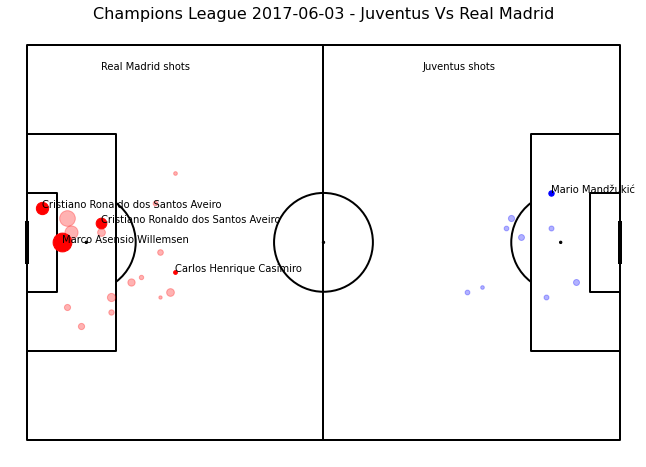

In [ ]:
plot_event_shots(matches, shots)

Importante, esta función solo sirve para los partidos de la champions, que solo hay un partido en el dataframe. Para otro dataframe que aparezcan más partidos, se debería de modificar para poder automatizar el proceso del título y el texto.

# 3.3. Visualizar el eventing pase
Una vez visualizado los tiros, pasemos a visualizar los pases. Nuevamente seleccionaremos la final de la Champions del 2019.



In [8]:
matches = f.info_json('/content/drive/MyDrive/Mi curso/Data/event_data/Statsbomb/data')
matches

**************************************
                Competition
id                         
16         Champions League
37  FA Women's Super League
43           FIFA World Cup
11                  La Liga
49                     NWSL
2            Premier League
72        Women's World Cup 

Que competición quieres analizar: 16
**************************************
       Season
id           
4   2018/2019
1   2017/2018
2   2016/2017
27  2015/2016
26  2014/2015
25  2013/2014
24  2012/2013
23  2011/2012
22  2010/2011
21  2009/2010
41  2008/2009
39  2006/2007
37  2004/2005
44  2003/2004
76  1999/2000 

Que temporada quieres analizar: 4


,home_team,away_team,home_score,away_score,match_date,competition,stage
match_id,,,,,,,
22912,Tottenham Hotspur,Liverpool,0,2,2019-06-01,Champions League,Final


Una vez seleccionado el partido, seleccionamos el tipo de evento.

In [9]:
pases = f.event_data('/content/drive/MyDrive/Mi curso/Data/event_data/Statsbomb/data/events', 22912)

['Starting XI' 'Half Start' 'Pass' 'Ball Receipt*' 'Carry' 'Duel'
 'Pressure' 'Foul Committed' 'Shot' 'Goal Keeper' 'Clearance'
 'Ball Recovery' 'Foul Won' 'Interception' 'Miscontrol' 'Dispossessed'
 'Dribbled Past' 'Dribble' '50/50' 'Block' 'Shield' 'Injury Stoppage'
 'Referee Ball-Drop' 'Half End' 'Substitution' 'Tactical Shift' 'Offside'] 

Que evento quieres analizar: Pass


Una vez seleccionado el evento Pass, vamos a seleccionar únicamente los pases de un equipo, ya que tendremos que hacerlo por separado. Empecemos filtrando los pases para el Liverpool.


In [10]:
liv_pas = pases[pases.team_name == 'Liverpool']

## 3.3.1. Visualizar los pases en forma de flechas
Una vez tenemos los pases del Liverpool, utilizaremos el método .arrows() para graficar los pases en forma de flecha, para indicar desde donde se produce el pase, la dirección, longitud del pase y su coordenada final.
 

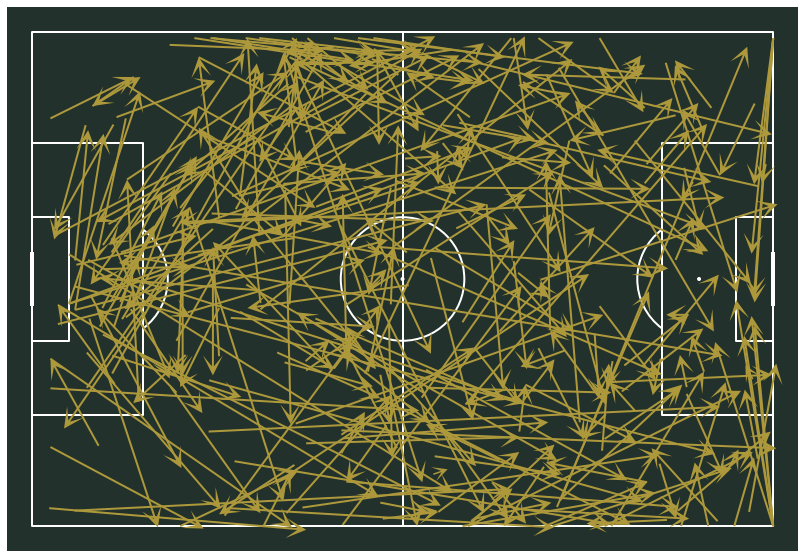

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
pitch = Pitch(pitch_color='#22312b', line_color='white')
pitch.draw(ax=ax)

pitch.arrows(liv_pas.location_x, liv_pas.location_y, 
             liv_pas.pass_end_location_x, liv_pas.pass_end_location_y, color = '#ad993c', ax=ax,
             width=2, headwidth=10, headlength=10)

## 3.3.2. Visualizar los pases exitosos y fallidos 
Una vez graficado todos los pases, si queremos hacer la diferencia entre pases exitosos y fallidos, tendremos que filtrar los datos. Primero analizaremos con .value_counts() la columna 'pass_outcome_name' que nos devuelve el resultado final del pase.  

In [ ]:
liv_pas.pass_outcome_name.value_counts(dropna=False)

NaN                 202
Incomplete           96
Out                  23
Unknown               2
Pass Offside          2
Injury Clearance      1
Name: pass_outcome_name, dtype: int64

Como hemos visto que los pases exitosos están puestos como valores nan, vamos a crear una máscara, para que podamos filtrar los datos para cuando sean exitosos o fallidos. Como los exitosos son los valores nan, utilizaremos el método .isnull() para saber si el valor del pase es nulo, si es así obtendremos como resultado el valor True.

In [ ]:
mask = liv_pas.pass_outcome_name.isnull()

Si miramos nuestra máscara, tendremos un montón de valores de True o False, dependiendo si el valor es un NaN o no y por tanto los True hacen referencia a los pases exitosos. 

In [ ]:
mask

4        True
7       False
11      False
16      False
20       True
        ...  
3144     True
3147     True
3150    False
3157     True
3160    False
Name: pass_outcome_name, Length: 326, dtype: bool

Una vez creada la máscara, utilizaremos mask para filtrar los datos a través de .loc pasandole mask a través de las filas, para que solo nos devuelva el valor de los pases exitosos.

In [ ]:
liv_pas.loc[mask, ['location_x', 'location_y']]

,location_x,location_y
4,61.0,41.0
20,60.4,20.5
24,65.6,19.3
27,65.2,25.2
65,44.6,1.0
...,...,...
3008,54.4,55.0
3141,40.9,53.5
3144,63.8,54.7
3147,97.6,61.3


Para los pases fallados, utilizaremos el símbolo de la ñ como vimos en el módulo 1 en la técnicas de filtrado. Con el signo de la ñ, negamos la máscara, por tanto el valor False pasa a ser True y el True pasa a ser False. Es un truco para poder obtener los pases fallados con la máscara que hemos creado. 

In [ ]:
liv_pas.loc[~mask, ['location_x', 'location_y']]

,location_x,location_y
7,37.0,44.9
11,66.5,15.1
16,76.1,20.3
30,107.0,24.3
44,15.4,8.6
...,...,...
3052,25.2,45.4
3077,14.4,35.7
3105,14.9,36.2
3150,93.5,56.7


Ahora simplemente tendremos que filtrar los datos en función de la máscara creada, también tendremos que utilizar dos veces .arrows(), una para los pases exitosos y  otra para los pases fallados. Recuerda cambiar el color de las flechas en los pases fallidos para que se pueda apreciar la diferencia

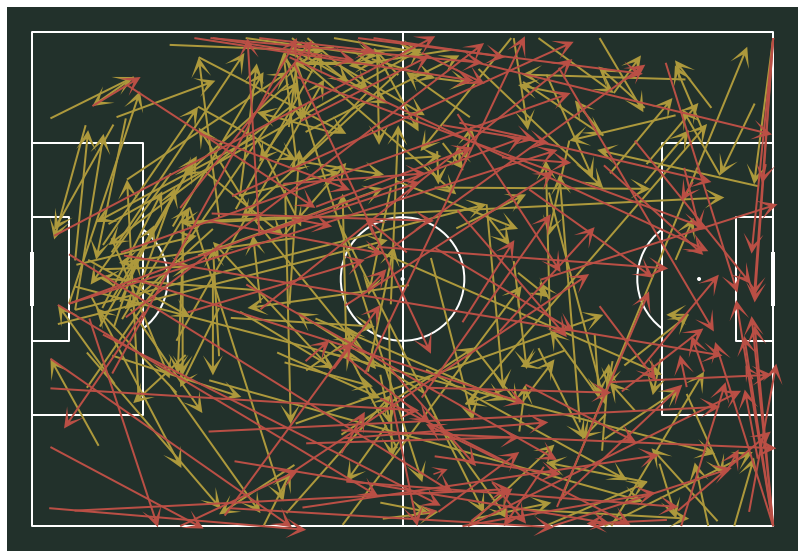

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
pitch = Pitch(pitch_color='#22312b', line_color='white')
pitch.draw(ax=ax)

pitch.arrows(liv_pas[mask].location_x, liv_pas[mask].location_y, 
             liv_pas[mask].pass_end_location_x, liv_pas[mask].pass_end_location_y, color = '#ad993c', ax=ax,
             width=2, headwidth=10, headlength=10)

pitch.arrows(liv_pas[~mask].location_x, liv_pas[~mask].location_y, 
             liv_pas[~mask].pass_end_location_x, liv_pas[~mask].pass_end_location_y, color ='#ba4f45', ax=ax,
             width=2, headwidth=10, headlength=10)

## 3.3.3. Añadir una leyenda
Podemos añadir una leyenda con .legend() y recuerda indicar al parámetro label en .arrows() el valor de cada flecha, para que sea vea en la leyenda que simboliza cada flecha.

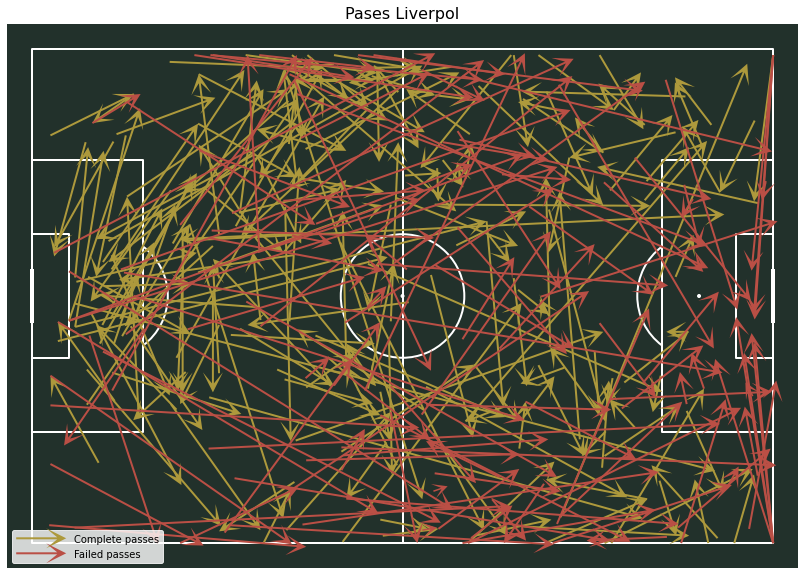

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
pitch = Pitch(pitch_color='#22312b', line_color='white')
pitch.draw(ax=ax)

pitch.arrows(liv_pas[mask].location_x, liv_pas[mask].location_y, 
             liv_pas[mask].pass_end_location_x, liv_pas[mask].pass_end_location_y, color = '#ad993c', ax=ax,
             width=2, headwidth=10, headlength=10, label='Complete passes')

pitch.arrows(liv_pas[~mask].location_x, liv_pas[~mask].location_y, 
             liv_pas[~mask].pass_end_location_x, liv_pas[~mask].pass_end_location_y, color ='#ba4f45', ax=ax,
             width=2, headwidth=10, headlength=10, label='Failed passes')

ax.legend(handlelength=5, edgecolor='white', fontsize=10, loc='lower left')
plt.title('Pases Liverpol', fontsize=16)
plt.show()

## 3.3.4. Automatizar todo el proceso
Encapsulamos el código dentro de nuestra función, para automatizar la visualización de los pases para cualquier partido.


In [ ]:
def draw_pass_event(df, team):

  df = df[df.team_name == team]
  mask = df.pass_outcome_name.isnull()

  fig, ax = plt.subplots(figsize=(15,10))
  pitch = Pitch(pitch_color='#22312b', line_color='white')
  pitch.draw(ax=ax)

  pitch.arrows(df[mask].location_x, df[mask].location_y, 
              df[mask].pass_end_location_x, df[mask].pass_end_location_y, color = '#ad993c', ax=ax,
              width=2, headwidth=10, headlength=10, label='Complete passes')

  pitch.arrows(df[~mask].location_x, df[~mask].location_y, 
              df[~mask].pass_end_location_x, df[~mask].pass_end_location_y, color ='#ba4f45', ax=ax,
              width=2, headwidth=10, headlength=10, label='Failed passes')

  ax.legend(handlelength=5, edgecolor='white', fontsize=10, loc='lower left')
  plt.title('Passes {}'.format(team), fontsize=16)
  plt.show()

Ahora en un momento podemos visualizar los pases exitosos y fallidos del Tottenham.


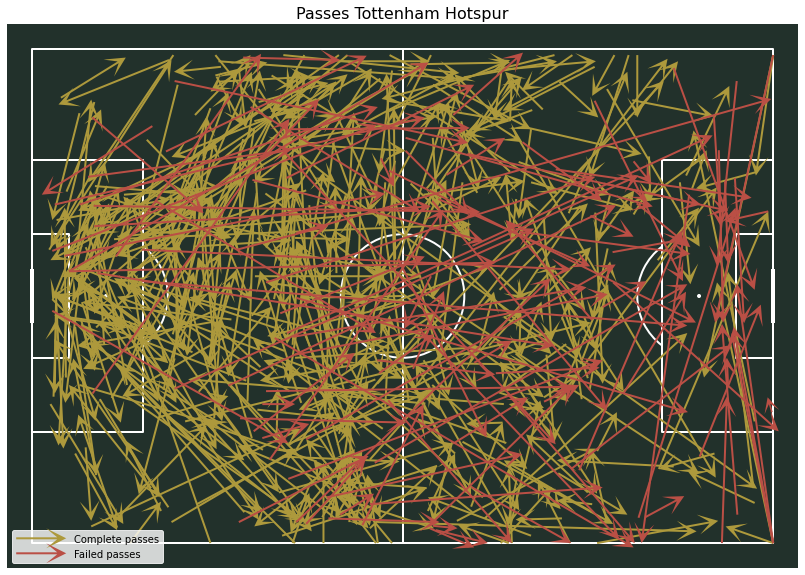

In [ ]:
draw_pass_event(pases, 'Tottenham Hotspur')

Esta función sirve para cualquier partido de cualquier competición.

#3.4. Mapa de calor
Después de graficar los pases, dada la cantidad de pases a veces cuesta un poco verle el sentido. Pero con los mapas de calor podemos ver mejor en qué zonas se producen los pases. Para crear el mapa de calor, utilizamos la librería seaborn. 
 


In [ ]:
import seaborn as sns

Visualizamos como siempre el campo de fútbol y para visualizar el mapa de calor utilizaremos sns.kedeplot()

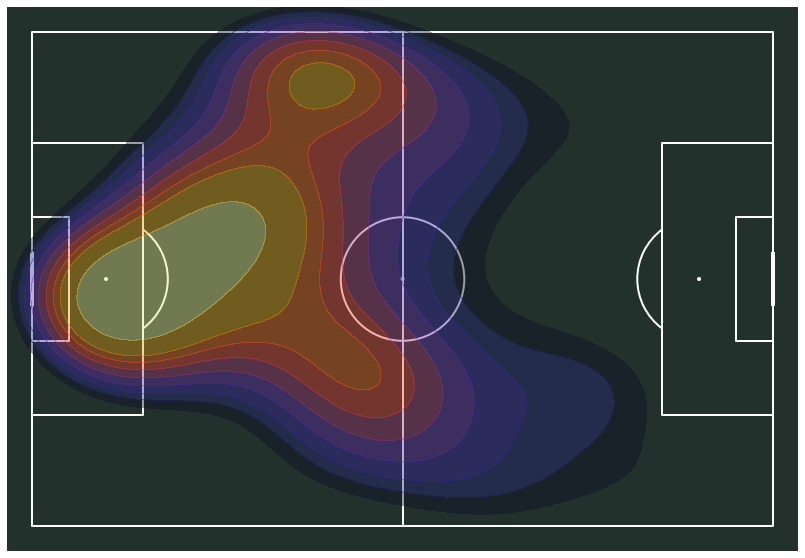

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
pitch = Pitch(pitch_color='#22312b', line_color='white')
pitch.draw(ax=ax)

kde = sns.kdeplot(x=liv_pas['location_x'], y=liv_pas['location_y'], shade=True, shade_lowest=False,
                  thresh=0.4, alpha=.4, n_levels=10, cmap='CMRmap')

plt.show()

Ahora tenemos una mapa de calor en donde realiza los pases el Liverpool. Podemos cambiar los datos y graficar donde finalizan los pases del Liverpool. 


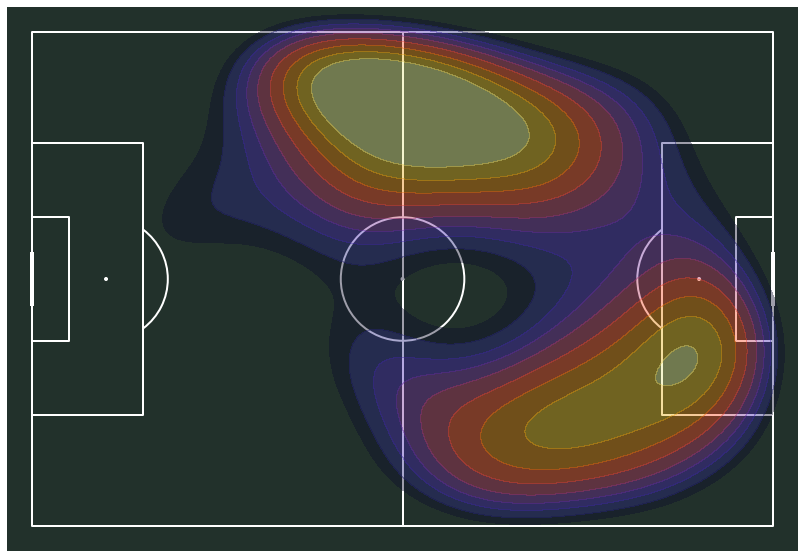

In [ ]:
fig, ax = plt.subplots(figsize=(15,10))
pitch = Pitch(pitch_color='#22312b', line_color='white')
pitch.draw(ax=ax)

kde = sns.kdeplot(x=liv_pas['pass_end_location_x'], y=liv_pas['pass_end_location_y'], shade=True, shade_lowest=False,
                  thresh=0.4, alpha=.4, n_levels=10, cmap='CMRmap')

plt.show()

## 3.4.1. Realizamos la automatización
Encapsulamos el código dentro de la función plot_heat_map_pass() para que sea más fácil la visualización del mapa de calor.

In [ ]:
def plot_heat_map_pass(df, team, x, y, title):

  df = df[df.team_name == team]
  fig, ax = plt.subplots(figsize=(15,10))
  pitch = Pitch(pitch_color='#22312b', line_color='white')
  pitch.draw(ax=ax)

  kde = sns.kdeplot(x=df[x], y=df[y], shade=True, shade_lowest=False,
                    thresh=0.4, alpha=.4, n_levels=10, cmap='CMRmap')
  plt.title(title, fontsize=16)

  plt.show()

Utilizamos la función para graficar los pases del Tottenham.

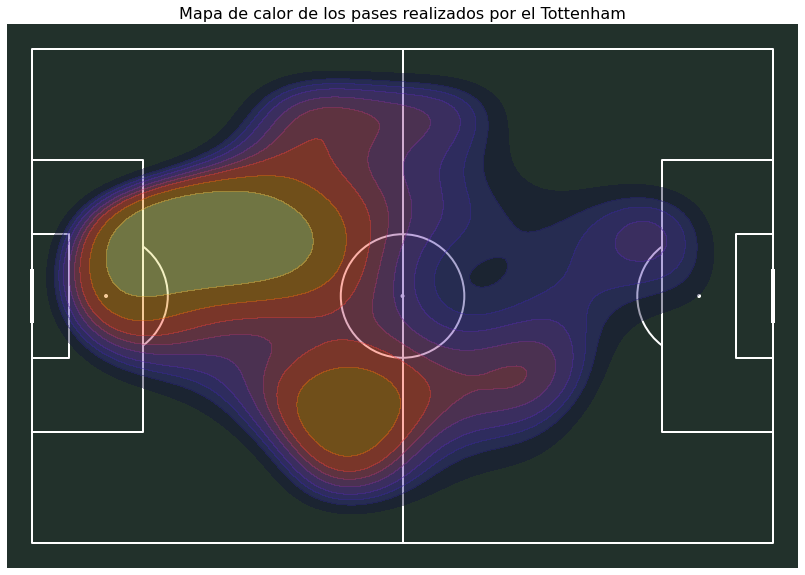

In [ ]:
plot_heat_map_pass(pases, 'Tottenham Hotspur', 'pass_end_location_x', 'pass_end_location_y', 'Mapa de calor de los pases realizados por el Tottenham')

Como veis, con el mapa de calor se puede ver un poco el patrón de los equipos. Ver como el Liverpool realiza  más pases en campo rival y el como el Tottenham realiza más pases, pero la mayoría de esos pases son en un propio campo.

# 3.5. La matriz de pases
Vamos a realizar una matriz de pases del partido de la final de la Champions. Con la matriz de pases vamos a poder ver entre qué jugadores se realizan los pases, sobre que zonas promedio realizan los pases y sobre qué jugador pasa o recibe más la pelota. Toda esa información la obtendremos de una matriz de pases. 

Para su visualización, necesitaremos realizar transformaciones a los datos, hasta tener los datos que nos permitan hacer este tipo de gráfico. 

El primer paso es quedarnos con los pases exitosos del Liverpool.


In [11]:
liv_pas = liv_pas[liv_pas.pass_outcome_name.isnull()]
len(liv_pas)

202

Vemos que tenemos una cantidad de 202 dos pases exitosos por parte del Liverpool.  Si seleccionamos las columnas 'player_name' y 'pass_recipient_name' veremos entre qué jugadores se producen los pases.


In [12]:
liv_pas[['player_name', 'pass_recipient_name']]

,player_name,pass_recipient_name
4,Jordan Brian Henderson,Joël Andre Job Matip
20,Virgil van Dijk,Georginio Wijnaldum
24,Georginio Wijnaldum,Jordan Brian Henderson
27,Jordan Brian Henderson,Sadio Mané
65,Andrew Robertson,Sadio Mané
...,...,...
3008,Trent Alexander-Arnold,Divock Okoth Origi
3141,Fábio Henrique Tavares,Divock Okoth Origi
3144,Divock Okoth Origi,Mohamed Salah
3147,Mohamed Salah,Divock Okoth Origi


Podemos extraer más información de estos pases. 

In [13]:
liv_pas[['player_name','location_x','location_y','pass_recipient_name', 'pass_end_location_x', 'pass_end_location_y']]

,player_name,location_x,location_y,pass_recipient_name,pass_end_location_x,pass_end_location_y
4,Jordan Brian Henderson,61.0,41.0,Joël Andre Job Matip,34.9,44.7
20,Virgil van Dijk,60.4,20.5,Georginio Wijnaldum,66.3,20.1
24,Georginio Wijnaldum,65.6,19.3,Jordan Brian Henderson,65.8,24.7
27,Jordan Brian Henderson,65.2,25.2,Sadio Mané,100.1,25.4
65,Andrew Robertson,44.6,1.0,Sadio Mané,54.5,9.4
...,...,...,...,...,...,...
3008,Trent Alexander-Arnold,54.4,55.0,Divock Okoth Origi,58.6,34.7
3141,Fábio Henrique Tavares,40.9,53.5,Divock Okoth Origi,55.2,57.4
3144,Divock Okoth Origi,63.8,54.7,Mohamed Salah,96.4,72.6
3147,Mohamed Salah,97.6,61.3,Divock Okoth Origi,93.5,56.7


Vamos a extraer las coordenadas promedio de cada jugador, en qué zonas en promedio realiza sus pases. Utilizaremos .groupby() para extraer este tipo de información.

In [14]:
avg = liv_pas.groupby('player_name').agg({'location_x':'mean', 'location_y':['mean', 'count']})
avg.columns = ['x_avg', 'y_avg', 'count']
avg

,x_avg,y_avg,count
player_name,,,
Alisson Ramsés Becker,11.064000,42.264000,25
Andrew Robertson,52.144118,8.932353,34
Divock Okoth Origi,65.250000,33.025000,4
Fábio Henrique Tavares,52.371429,42.200000,14
Georginio Wijnaldum,74.150000,31.325000,12
James Philip Milner,49.150000,26.300000,4
Jordan Brian Henderson,75.256250,49.418750,16
Joël Andre Job Matip,40.016667,50.905556,18
Mohamed Salah,96.628571,52.957143,7


Ahora que tenemos las coordenadas promedio, vamos a extraer la cantidad de pases entre jugadores. Nuevamente utilizaremos un .groupby() para conseguirlo.

In [15]:
btw = liv_pas.groupby(['player_name', 'pass_recipient_name']).id.count().reset_index()
btw

,player_name,pass_recipient_name,id
0,Alisson Ramsés Becker,Andrew Robertson,6
1,Alisson Ramsés Becker,Fábio Henrique Tavares,3
2,Alisson Ramsés Becker,James Philip Milner,2
3,Alisson Ramsés Becker,Joël Andre Job Matip,3
4,Alisson Ramsés Becker,Mohamed Salah,1
...,...,...,...
90,Virgil van Dijk,Jordan Brian Henderson,2
91,Virgil van Dijk,Joël Andre Job Matip,5
92,Virgil van Dijk,Mohamed Salah,2
93,Virgil van Dijk,Sadio Mané,1


Vamos a realizar un merge entre los dos dataframes que acabamos de crear. El .merge() es una manera diferente a .concat() de juntar dos dataframes. Utilizamos .merge() cuando los datos son de diferente tamaño, están desordenados y no tiene las mismas columnas. Eso sí, hace falta que los dos dataframes compartan una misma columna, en este caso es 'player_name'.

In [16]:
merg1 = btw.merge(avg, left_on='player_name', right_index=True)
merg1

,player_name,pass_recipient_name,id,x_avg,y_avg,count
0,Alisson Ramsés Becker,Andrew Robertson,6,11.064,42.264,25
1,Alisson Ramsés Becker,Fábio Henrique Tavares,3,11.064,42.264,25
2,Alisson Ramsés Becker,James Philip Milner,2,11.064,42.264,25
3,Alisson Ramsés Becker,Joël Andre Job Matip,3,11.064,42.264,25
4,Alisson Ramsés Becker,Mohamed Salah,1,11.064,42.264,25
...,...,...,...,...,...,...
90,Virgil van Dijk,Jordan Brian Henderson,2,30.880,31.056,25
91,Virgil van Dijk,Joël Andre Job Matip,5,30.880,31.056,25
92,Virgil van Dijk,Mohamed Salah,2,30.880,31.056,25
93,Virgil van Dijk,Sadio Mané,1,30.880,31.056,25


El merger lo hemos hecho para añadir las coordenadas promedio que antes conseguimos en los pases entre jugadores. Vamos a realizar otro merge para tener también las coordenadas promedio del jugador que recibe el pase.

In [17]:
pass_btw = merg1.merge(avg, left_on='pass_recipient_name', right_index=True, suffixes=['', '_end'])
pass_btw

,player_name,pass_recipient_name,id,x_avg,y_avg,count,x_avg_end,y_avg_end,count_end
0,Alisson Ramsés Becker,Andrew Robertson,6,11.064000,42.264000,25,52.144118,8.932353,34
23,Fábio Henrique Tavares,Andrew Robertson,3,52.371429,42.200000,14,52.144118,8.932353,34
31,Georginio Wijnaldum,Andrew Robertson,2,74.150000,31.325000,12,52.144118,8.932353,34
38,James Philip Milner,Andrew Robertson,1,49.150000,26.300000,4,52.144118,8.932353,34
42,Jordan Brian Henderson,Andrew Robertson,2,75.256250,49.418750,16,52.144118,8.932353,34
...,...,...,...,...,...,...,...,...,...
35,Georginio Wijnaldum,Roberto Firmino Barbosa de Oliveira,2,74.150000,31.325000,12,94.775000,37.387500,8
55,Joël Andre Job Matip,Roberto Firmino Barbosa de Oliveira,1,40.016667,50.905556,18,94.775000,37.387500,8
62,Mohamed Salah,Roberto Firmino Barbosa de Oliveira,2,96.628571,52.957143,7,94.775000,37.387500,8
75,Sadio Mané,Roberto Firmino Barbosa de Oliveira,1,71.950000,20.866667,18,94.775000,37.387500,8


Ahora tenemos toda la información que nos interesa, solo vamos hacer un último .groupby() para saber que jugador recibe más la pelota.

In [18]:
pas_rec = pass_btw.groupby('pass_recipient_name').id.sum()
pas_rec

pass_recipient_name
Alisson Ramsés Becker                  13
Andrew Robertson                       29
Divock Okoth Origi                     12
Fábio Henrique Tavares                 13
Georginio Wijnaldum                     9
James Philip Milner                     6
Jordan Brian Henderson                 16
Joël Andre Job Matip                   11
Mohamed Salah                          19
Roberto Firmino Barbosa de Oliveira    13
Sadio Mané                             28
Trent Alexander-Arnold                 15
Virgil van Dijk                        18
Name: id, dtype: int64

Al dataframe que creamos donde salían las coordenadas promedio de los pases, vamos a añadir la información de la cantidad de pases que realizan y  reciben. Todo ello esta vez con .concat()

In [19]:
new_avg = pd.concat([avg, pas_rec], axis=1)
new_avg

,x_avg,y_avg,count,id
Alisson Ramsés Becker,11.064000,42.264000,25,13
Andrew Robertson,52.144118,8.932353,34,29
Divock Okoth Origi,65.250000,33.025000,4,12
Fábio Henrique Tavares,52.371429,42.200000,14,13
Georginio Wijnaldum,74.150000,31.325000,12,9
James Philip Milner,49.150000,26.300000,4,6
Jordan Brian Henderson,75.256250,49.418750,16,16
Joël Andre Job Matip,40.016667,50.905556,18,11
Mohamed Salah,96.628571,52.957143,7,19
Roberto Firmino Barbosa de Oliveira,94.775000,37.387500,8,13


Ahora podemos ver que pareja de jugadores realizó más pases entre ellos.

In [20]:
pass_btw[pass_btw.id == pass_btw.id.max()]

,player_name,pass_recipient_name,id,x_avg,y_avg,count,x_avg_end,y_avg_end,count_end
16,Andrew Robertson,Sadio Mané,10,52.144118,8.932353,34,71.95,20.866667,18


## 3.5.1. Visualizar la matriz de pases
Ahora tenemos todos los ingredientes para empezar a visualizar la matriz de pases. 


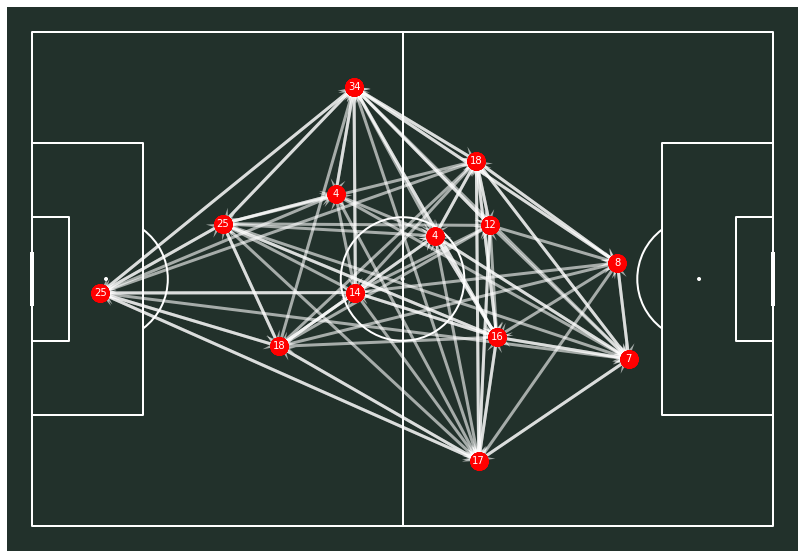

In [21]:
fig, ax = plt.subplots(figsize=(15,10))
pitch = Pitch(pitch_color='#22312b', line_color='white')
pitch.draw(ax=ax)

pitch.arrows(pass_btw.x_avg, pass_btw.y_avg, pass_btw.x_avg_end, pass_btw.y_avg_end, ax=ax, 
             color='white', width=3, headwidth=5, headaxislength=3, headlength=5, zorder=1, 
             alpha=0.6)

pitch.scatter(pass_btw.x_avg, pass_btw.y_avg, s=300, color='red', ax=ax)

for i in range(len(avg)):
  pitch.annotate(avg['count'].values[i], xy=(avg['x_avg'].values[i],avg['y_avg'].values[i]),
                 ax=ax, va='center', ha='center',color ='white')

Esto empieza a coger forma, pero vamos a utilizar un bucle for para graficar las conexiones y que su grosor vaya relacionado con la cantidad de pases entre jugadores, para ver visualmente si hay bastantes pases entre los jugadores. También añadiremos la cantidad de pases que reciben y realizan cada jugador.

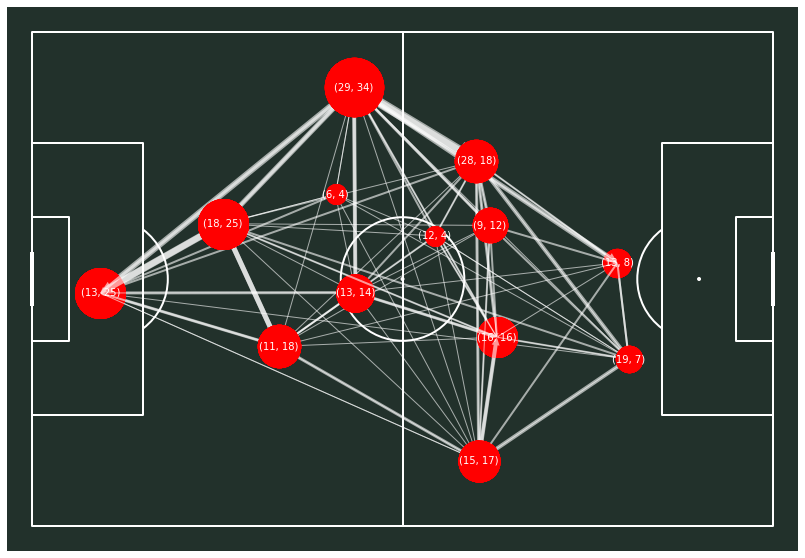

In [22]:
fig, ax = plt.subplots(figsize=(15,10))
pitch = Pitch(pitch_color='#22312b', line_color='white')
pitch.draw(ax=ax)

for i in range(len(pass_btw)):

  pitch.arrows(pass_btw.x_avg.values[i], pass_btw.y_avg.values[i],pass_btw.x_avg_end.values[i],
               pass_btw.y_avg_end.values[i], ax=ax, color='white', 
               width=pass_btw.id.values[i], headwidth=2, headaxislength=2,
               headlength=2, zorder=1, alpha=0.6)

  pitch.scatter(pass_btw.x_avg.values[i], pass_btw.y_avg.values[i],     
                s=pass_btw['count'].values[i]*100, color='red', ax=ax)

for i in range(len(avg)):
  pitch.annotate((new_avg['id'].values[i], new_avg['count'].values[i]),  
                 xy=(new_avg['x_avg'].values[i], new_avg['y_avg'].values[i]), ax=ax,     
                 va='center', ha='center',color ='white')

Ahora ya podemos ver los pases entre jugadores, que jugador recibe y pasa más la pelota y a que jugadores se la pasa mas. También podemos ver las coordenadas promedio donde se realizan dichos pases. 
## 3.5.2. Automatizar el proceso 
Vamos automatizar todo el proceso, encapsulando todo el código dentro de la función plot_pass_matrix()


In [23]:
def plot_pass_matrix(df, team):

  df = df[df.team_name == team]
  df_pas = df[df.pass_outcome_name.isnull()]

  avg = df_pas.groupby('player_name').agg({'location_x':'mean', 'location_y':['mean',      
                                           'count']})
  avg.columns = ['x_avg', 'y_avg', 'count']

  btw = df_pas.groupby(['player_name', 'pass_recipient_name']).id.count().reset_index()

  merg1 = btw.merge(avg, left_on='player_name', right_index=True)
  pass_btw = merg1.merge(avg, left_on='pass_recipient_name',
                         right_index=True, suffixes=['', '_end'])

  pas_rec = pass_btw.groupby('pass_recipient_name').id.sum()
  new_avg = pd.concat([avg, pas_rec],axis=1)

  fig, ax = plt.subplots(figsize=(15,10))
  pitch = Pitch(pitch_color='#22312b', line_color='white')
  pitch.draw(ax=ax)


  for i in range(len(pass_btw)):

    arrows = pitch.arrows(pass_btw.x_avg.values[i], pass_btw.y_avg.values[i], 
                          pass_btw.x_avg_end.values[i], pass_btw.y_avg_end.values[i], ax=ax,
                          color='white', width=pass_btw.id.values[i], headwidth=2,headlength=2,   
                          headaxislength=2, zorder=1, alpha=0.5)

    nodes = pitch.scatter(pass_btw.x_avg.values[i], pass_btw.y_avg.values[i],   
                          s=pass_btw['count'].values[i]*100, color='red', ax=ax, alpha=0.5)

  for i in range(len(avg)):
    pitch.annotate((new_avg['id'].values[i] ,new_avg['count'].values[i]),  
                    xy=(new_avg['x_avg'].values[i], new_avg['y_avg'].values[i]), ax=ax,    
                    va='center', ha='center',color ='white')

Ahora podemos de una manera muy sencilla graficar la matriz de pases de cualquier equipo y podemos comparar la matriz de pases de ambos equipos. 


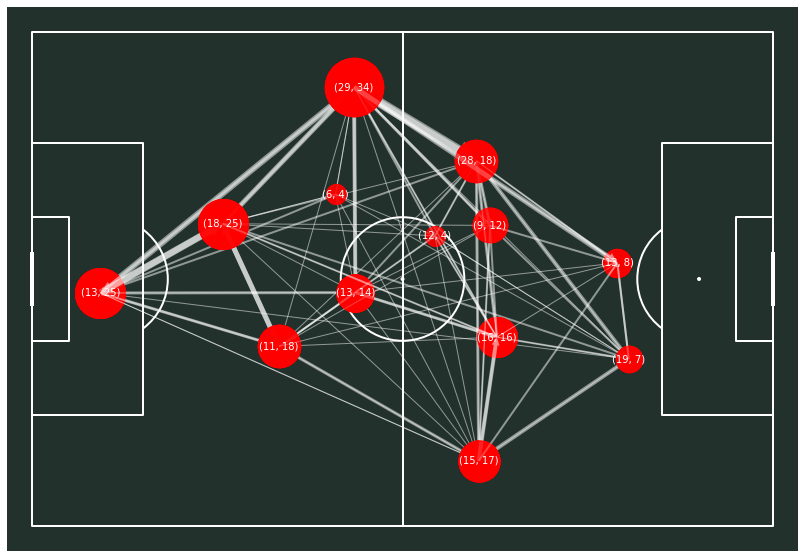

In [24]:
plot_pass_matrix(pases, 'Liverpool')

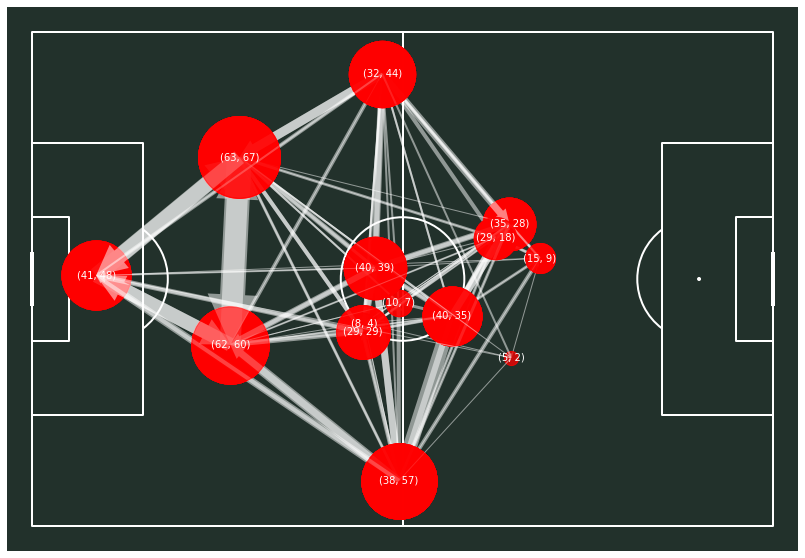

In [25]:
plot_pass_matrix(pases, 'Tottenham Hotspur')